# Predicting Ocean pCO2 from Satellite Data

**Goal:** Train machine learning models to predict daily mean surface ocean pCO2 (partial pressure of CO2) using satellite-derived SST and chlorophyll-a features.

**Input:** `training_data_700_ml_ready.csv` — 479 buoy-days across 7 NOAA sites, each with:
- 7 satellite SST summary features (mean, std, min, max, median, closest, n_pixels)
- 8 satellite chl-a features (same stats + days_offset to nearest composite)
- In-situ SST from the buoy
- Location coordinates (lat, lon)

**Target:** `pco2_mean` — daily mean pCO2 in µatm

**Models tested:**
1. Linear Regression (simple baseline)
2. Random Forest

**Evaluation:** 80/20 train/test split, measured by RMSE and R²

In [1]:
# ============================================================
# Cell 1: Imports
# ============================================================
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_theme(style="whitegrid", font_scale=1.1)

print("Python:", sys.version)
print("scikit-learn:", __import__('sklearn').__version__)

Python: 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]
scikit-learn: 1.8.0


## Step 1 — Load and Inspect the Training Data

We load the ML-ready CSV (only rows where both satellite SST and chl-a are present).
Then we pick which columns are **features** (inputs) and which is the **target** (what we predict).

In [2]:
# ============================================================
# Cell 2: Load data + define features and target
# ============================================================
PROJECT_ROOT = Path(r"C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PLOT_DIR = PROJECT_ROOT / "plots" / "ml_results"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DIR / "training_data_700_ml_ready.csv")
df["date"] = pd.to_datetime(df["date"])

print(f"Dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Sites: {df['location'].nunique()}")
print()

# --- Define feature columns and target ---
# We use satellite-derived features + location + in-situ SST
FEATURE_COLS = [
    "latitude", "longitude",
    "sst_in_situ_mean",
    "sat_sst_mean", "sat_sst_std", "sat_sst_min", "sat_sst_max",
    "sat_sst_median", "sat_sst_closest",
    "sat_chla_mean", "sat_chla_std", "sat_chla_min", "sat_chla_max",
    "sat_chla_median", "sat_chla_closest",
    "chla_days_offset",
]
TARGET = "pco2_mean"

print(f"Features ({len(FEATURE_COLS)}):")
for f in FEATURE_COLS:
    print(f"  - {f}")
print(f"\nTarget: {TARGET}")
print(f"\nTarget stats:")
display(df[TARGET].describe())

Dataset: 479 rows x 22 columns
Sites: 7

Features (16):
  - latitude
  - longitude
  - sst_in_situ_mean
  - sat_sst_mean
  - sat_sst_std
  - sat_sst_min
  - sat_sst_max
  - sat_sst_median
  - sat_sst_closest
  - sat_chla_mean
  - sat_chla_std
  - sat_chla_min
  - sat_chla_max
  - sat_chla_median
  - sat_chla_closest
  - chla_days_offset

Target: pco2_mean

Target stats:


count    479.000000
mean     391.032398
std       92.391912
min      118.550000
25%      338.398125
50%      397.912500
75%      451.250000
max      767.162500
Name: pco2_mean, dtype: float64

## Step 2 — Train/Test Split

We hold out **20% of the data** for testing. The model never sees these rows during training — this tells us how well the model generalizes to new data.

We also **standardize** (z-score normalize) the features so each one has mean=0 and std=1. This helps Linear Regression and makes feature importance more comparable. Tree-based models don't strictly need it, but it doesn't hurt.

In [3]:
# ============================================================
# Cell 3: Train/Test split + scaling
# ============================================================
X = df[FEATURE_COLS].copy()
y = df[TARGET].copy()

# Check for any NaN values in features and fill them
nan_counts = X.isna().sum()
if nan_counts.any():
    print("NaN values found in features (filling with column median):")
    print(nan_counts[nan_counts > 0].to_string())
    X = X.fillna(X.median())
    print()

# 80/20 split, stratify by location to keep site proportions balanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42,
    stratify=df["location"]  # keeps each site proportionally represented
)

print(f"Training set: {len(X_train)} rows")
print(f"Test set:     {len(X_test)} rows")
print()

# Standardize features (fit on train only, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep as DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=FEATURE_COLS, index=X_test.index)

print("Scaling check (train means should be ~0):")
print(X_train_scaled.mean().round(2).to_string())


NaN values found in features (filling with column median):
sat_chla_std    6

Training set: 383 rows
Test set:     96 rows

Scaling check (train means should be ~0):
latitude            0.0
longitude           0.0
sst_in_situ_mean   -0.0
sat_sst_mean        0.0
sat_sst_std        -0.0
sat_sst_min         0.0
sat_sst_max        -0.0
sat_sst_median     -0.0
sat_sst_closest    -0.0
sat_chla_mean       0.0
sat_chla_std       -0.0
sat_chla_min        0.0
sat_chla_max       -0.0
sat_chla_median     0.0
sat_chla_closest   -0.0
chla_days_offset    0.0


## Step 3 — Train Two Models

We train two different regression models and compare them:

1. **Linear Regression** — the simplest possible model. Fits a straight line through the features. Good baseline to beat.
2. **Random Forest** — an ensemble of many decision trees, each trained on a random subset of the data. Handles non-linear relationships well.

For each model we predict on the **test set** and compute:
- **RMSE** (Root Mean Squared Error) — average prediction error in µatm (lower is better)
- **MAE** (Mean Absolute Error) — similar but less sensitive to outliers
- **R²** (coefficient of determination) — fraction of variance explained (1.0 = perfect, 0.0 = no skill)

In [4]:
# ============================================================
# Cell 4: Train both models + evaluate
# ============================================================

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,    # number of trees
        max_depth=12,        # how deep each tree can grow
        min_samples_leaf=5,  # minimum samples in a leaf node
        random_state=42,
        n_jobs=-1,           # use all CPU cores
    ),
}

results = []
predictions = {}  # store predictions for plotting

for name, model in models.items():
    print(f"Training {name}...")
    
    # Linear regression uses scaled features; tree models use raw
    if "Linear" in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({"Model": name, "RMSE (uatm)": round(rmse, 1),
                    "MAE (uatm)": round(mae, 1), "R2": round(r2, 3)})
    predictions[name] = y_pred
    
    print(f"  RMSE = {rmse:.1f} uatm | MAE = {mae:.1f} uatm | R2 = {r2:.3f}")
    print()

# Summary table
results_df = pd.DataFrame(results)
print("=" * 55)
print("MODEL COMPARISON")
print("=" * 55)
display(results_df)

Training Linear Regression...
  RMSE = 83.3 uatm | MAE = 55.6 uatm | R2 = 0.281

Training Random Forest...
  RMSE = 71.8 uatm | MAE = 43.6 uatm | R2 = 0.465

MODEL COMPARISON


,Model,RMSE (uatm),MAE (uatm),R2
0,Linear Regression,83.3,55.6,0.281
1,Random Forest,71.8,43.6,0.465


## Step 4 — Predicted vs Actual (Visual Check)

The most intuitive way to judge a regression model: plot **predicted pCO2** (y-axis) against **actual pCO2** (x-axis) for the test set. Perfect predictions would fall exactly on the 1:1 diagonal line. Points scattered far from the line are where the model struggles.

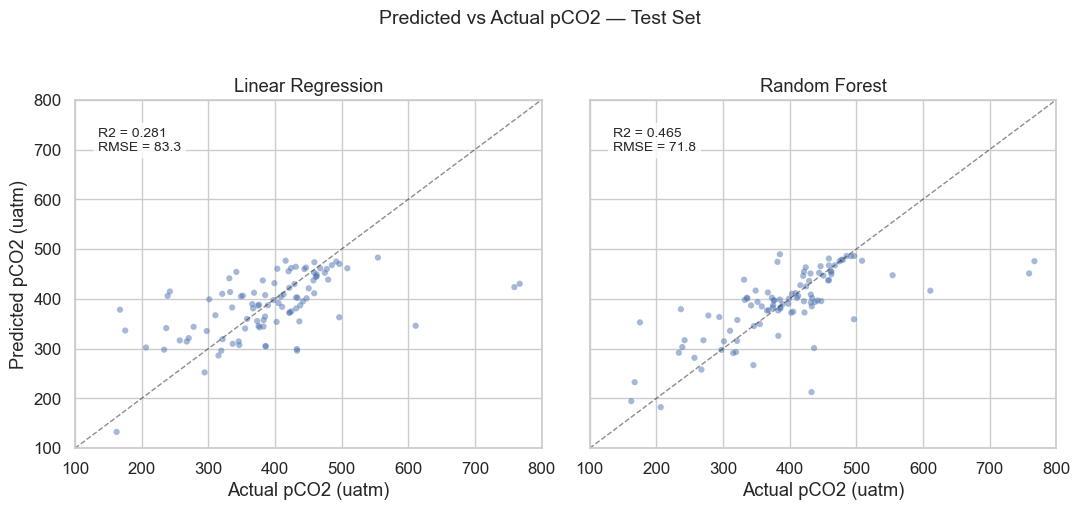

Saved -> C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject\plots\ml_results\01_predicted_vs_actual.png


In [5]:
# ============================================================
# Cell 5: Predicted vs Actual — one panel per model
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for ax, (name, y_pred) in zip(axes, predictions.items()):
    r2 = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    
    ax.scatter(y_test, y_pred, alpha=0.5, s=20, edgecolors="none")
    
    # 1:1 line
    lims = [100, 800]
    ax.plot(lims, lims, "k--", lw=1, alpha=0.5)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    
    ax.set_title(name)
    ax.set_xlabel("Actual pCO2 (uatm)")
    ax.text(0.05, 0.92, f"R2 = {r2:.3f}\nRMSE = {rmse:.1f}",
            transform=ax.transAxes, fontsize=10, va="top",
            bbox=dict(boxstyle="round", fc="white", alpha=0.8))

axes[0].set_ylabel("Predicted pCO2 (uatm)")

fig.suptitle("Predicted vs Actual pCO2 — Test Set", fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(PLOT_DIR / "01_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOT_DIR / '01_predicted_vs_actual.png'}")

## Step 5 — Residual Analysis

**Residuals** = Actual - Predicted. Ideally these should be centered around zero with no obvious patterns. If we see residuals that depend on the predicted value, it means the model is systematically over- or under-predicting in certain ranges.

Showing residuals for best model: Random Forest
  Mean residual:   2.51 uatm (should be ~0)
  Std residual:    71.80 uatm



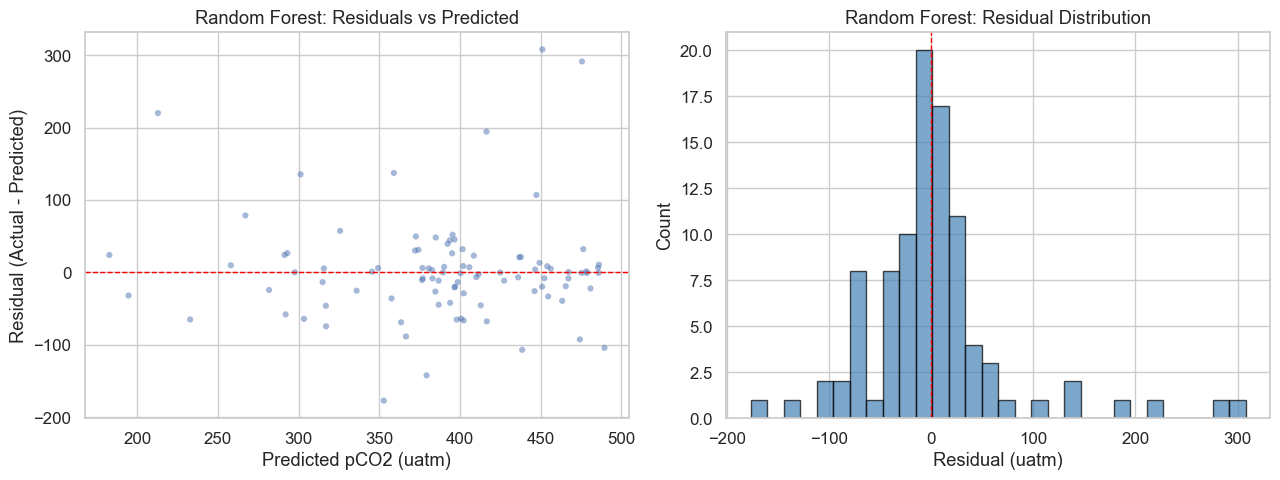

Saved -> C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject\plots\ml_results\02_residuals.png


In [6]:
# ============================================================
# Cell 6: Residual plots for the best model
# ============================================================

# Pick the model with the lowest RMSE
best_name = results_df.loc[results_df["RMSE (uatm)"].idxmin(), "Model"]
best_pred = predictions[best_name]
residuals = y_test.values - best_pred

print(f"Showing residuals for best model: {best_name}")
print(f"  Mean residual:   {residuals.mean():.2f} uatm (should be ~0)")
print(f"  Std residual:    {residuals.std():.2f} uatm")
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: residuals vs predicted
ax = axes[0]
ax.scatter(best_pred, residuals, alpha=0.5, s=20, edgecolors="none")
ax.axhline(y=0, color="red", ls="--", lw=1)
ax.set_xlabel("Predicted pCO2 (uatm)")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title(f"{best_name}: Residuals vs Predicted")

# Right: histogram of residuals
ax = axes[1]
ax.hist(residuals, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
ax.axvline(x=0, color="red", ls="--", lw=1)
ax.set_xlabel("Residual (uatm)")
ax.set_ylabel("Count")
ax.set_title(f"{best_name}: Residual Distribution")

plt.tight_layout()
fig.savefig(PLOT_DIR / "02_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOT_DIR / '02_residuals.png'}")

## Step 6 — Feature Importance

Which features matter most for predicting pCO2? Tree-based models can tell us how much each feature contributed to reducing prediction error. This helps us understand **what drives ocean pCO2 variability** — not just make predictions, but learn something about the ocean.

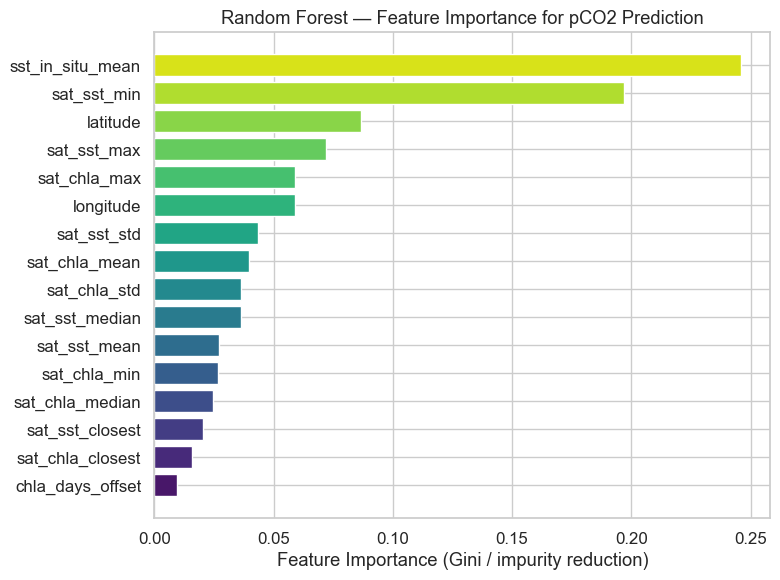

Saved -> C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject\plots\ml_results\03_feature_importance.png

Top 5 features:


,feature,importance
2,sst_in_situ_mean,0.246039
5,sat_sst_min,0.196883
0,latitude,0.086688
6,sat_sst_max,0.072167
12,sat_chla_max,0.058988


In [7]:
# ============================================================
# Cell 7: Feature importance from Random Forest
# ============================================================

rf_model = models["Random Forest"]
importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": importances
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = sns.color_palette("viridis", n_colors=len(feat_imp))
ax.barh(feat_imp["feature"], feat_imp["importance"], color=colors)
ax.set_xlabel("Feature Importance (Gini / impurity reduction)")
ax.set_title("Random Forest — Feature Importance for pCO2 Prediction")

plt.tight_layout()
fig.savefig(PLOT_DIR / "03_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOT_DIR / '03_feature_importance.png'}")

print("\nTop 5 features:")
display(feat_imp.sort_values("importance", ascending=False).head(5))

## Step 7 — Predictions by Site

Does the model work equally well at all buoy locations? Some sites may be harder to predict than others — for example, coastal estuary sites with complex dynamics might have higher errors than open-ocean sites.

Per-site performance (Random Forest):


,Site,N_test,RMSE,R2
5,South Pacific,15,13.5,0.664
1,Grays Reef Georgia,14,36.6,0.437
6,Southern California,17,56.9,0.033
3,La Push,14,59.7,-0.025
2,LA Buoy,9,61.0,0.289
4,SE Bering Sea,7,88.9,-0.155
0,First Landing,20,118.3,0.302


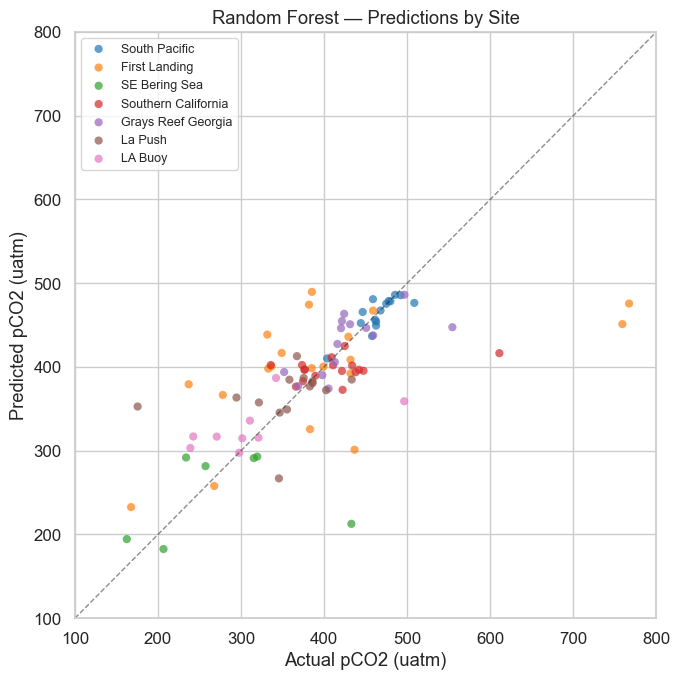

Saved -> C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject\plots\ml_results\04_predictions_by_site.png


In [8]:
# ============================================================
# Cell 8: Per-site performance breakdown
# ============================================================

# Build a test-set DataFrame with predictions
test_df = df.loc[X_test.index].copy()
test_df["predicted_pco2"] = best_pred
test_df["residual"] = test_df["pco2_mean"] - test_df["predicted_pco2"]

# Per-site metrics
site_metrics = []
for site, g in test_df.groupby("location"):
    rmse = (g["residual"] ** 2).mean() ** 0.5
    r2 = r2_score(g["pco2_mean"], g["predicted_pco2"]) if len(g) > 1 else float("nan")
    site_metrics.append({"Site": site, "N_test": len(g),
                         "RMSE": round(rmse, 1), "R2": round(r2, 3)})

site_df = pd.DataFrame(site_metrics).sort_values("RMSE")
print(f"Per-site performance ({best_name}):")
display(site_df)

# Plot: predicted vs actual colored by site
fig, ax = plt.subplots(figsize=(7, 7))
sites = test_df["location"].unique()
palette = dict(zip(sites, sns.color_palette("tab10", n_colors=len(sites))))

for site in sites:
    sub = test_df[test_df["location"] == site]
    ax.scatter(sub["pco2_mean"], sub["predicted_pco2"],
               label=site, alpha=0.7, s=35, color=palette[site], edgecolors="none")

lims = [100, 800]
ax.plot(lims, lims, "k--", lw=1, alpha=0.5)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual pCO2 (uatm)")
ax.set_ylabel("Predicted pCO2 (uatm)")
ax.set_title(f"{best_name} — Predictions by Site")
ax.legend(fontsize=9, loc="upper left")

plt.tight_layout()
fig.savefig(PLOT_DIR / "04_predictions_by_site.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOT_DIR / '04_predictions_by_site.png'}")

## Summary

This notebook demonstrated a complete ML workflow:

1. **Load** a pre-built training dataset (satellite SST + chl-a matched to buoy pCO2)
2. **Split** into train/test sets (80/20)
3. **Train** two models of increasing complexity
4. **Evaluate** with RMSE, MAE, R2 and visual diagnostics
5. **Interpret** with feature importance and per-site breakdown

### Key takeaways:
- Random Forest substantially outperforms linear regression for this problem
- The non-linear relationships between SST, chl-a, and pCO2 vary by ocean region — linear models can't capture this
- Feature importance reveals which satellite measurements matter most for pCO2 prediction
- Some sites are harder to predict than others, reflecting real physical differences in ocean carbon dynamics